In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


In [2]:
# ==============================================================================
# STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING
# ==============================================================================
"""
BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:
┌────────────────────┐     ┌────────────────────┐     ┌────────────────────┐
│ Stage 1: Context   │ ──> │ Stage 2: Profiling │ ──> │ Stage 3: Univariate│
└────────────────────┘     └────────────────────┘     └────────────────────┘
                                                                 │
┌────────────────────┐     ┌────────────────────┐     ┌──────────┴─────────┐
│ Stage 6: Insights  │ <── │ Stage 5: Multivar  │ <── │ Stage 4: Bivariate │
└────────────────────┘     └────────────────────┘     └────────────────────┘
"""
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [3]:
# ==============================================================================
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT
# ==============================================================================
print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---")
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))

print("\n--- 4. Categorical Cardinality & Balance ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_1502/278002177.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])


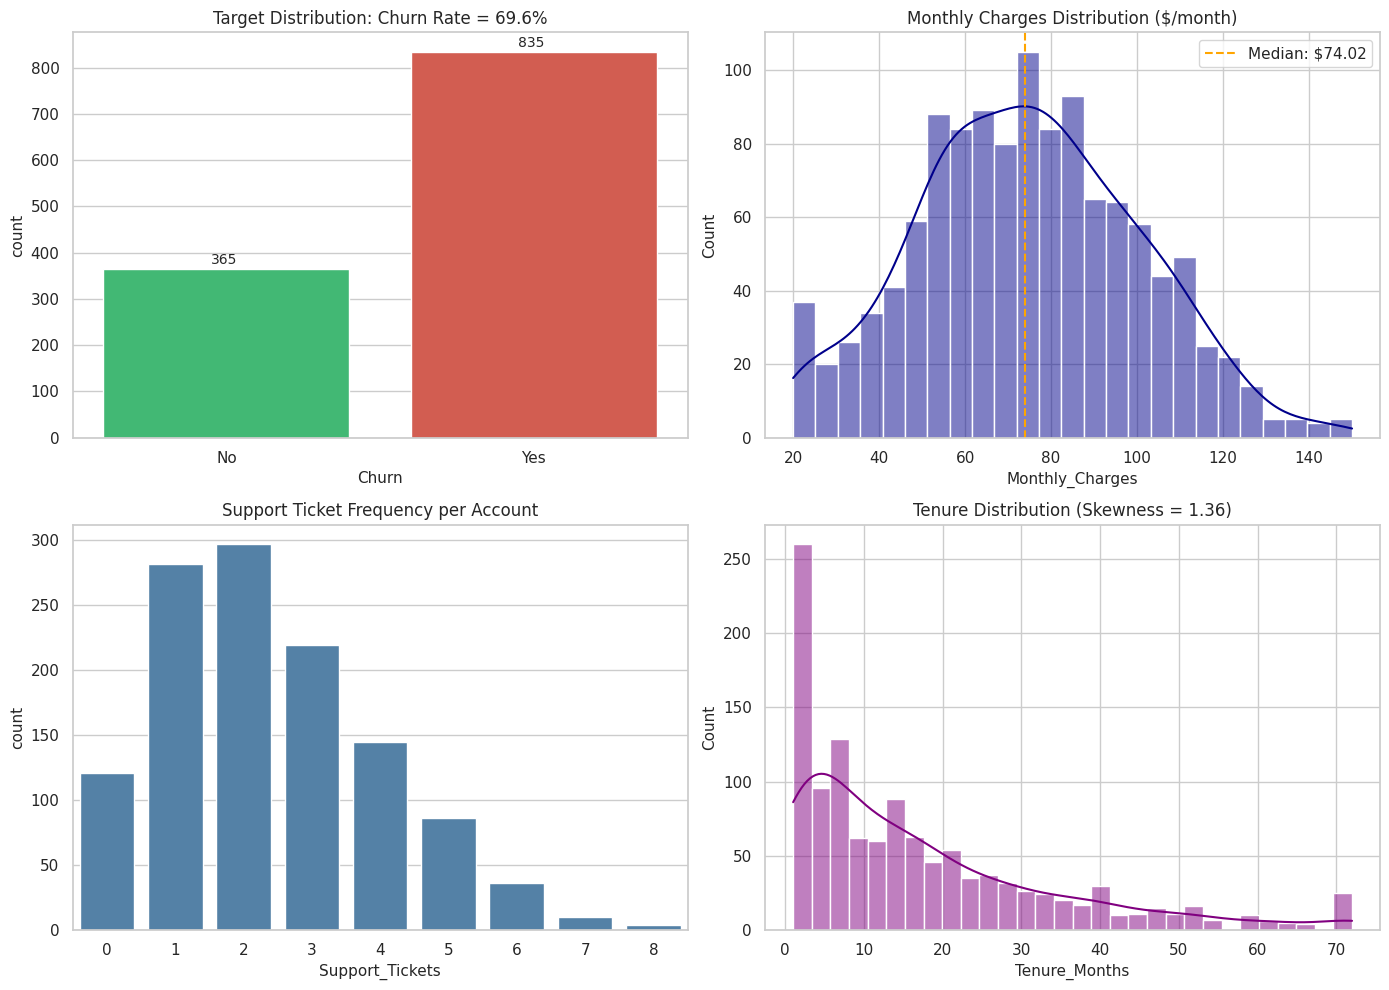

In [4]:
# ==============================================================================
# STAGE 3: UNIVARIATE ANALYSIS
# ==============================================================================
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30)
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()

# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

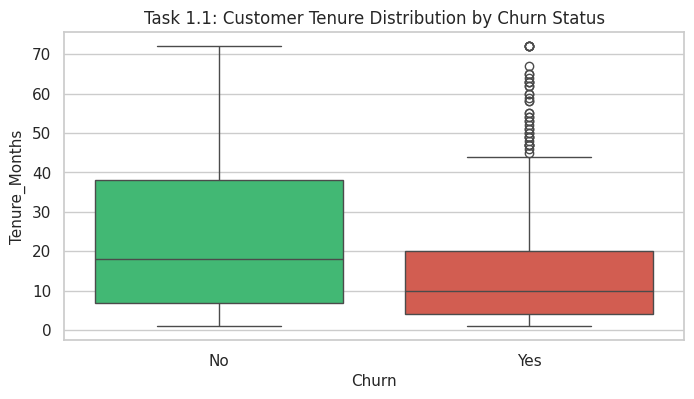

--- Tenure Statistics by Churn Group ---
       median   IQR
Churn              
No       18.0  31.0
Yes      10.0  16.0

Kruskal-Wallis H-test (Tenure vs Churn): H-stat=54.23, p-value=1.7834e-13

--- Churn Rates across Contract & Tech Support ---


Churn                              No       Yes
Contract_Type  Tech_Support                    
Month-to-Month No            0.138614  0.861386
               No internet   0.151786  0.848214
               Yes           0.152893  0.847107
One-Year       No            0.318841  0.681159
               No internet   0.404762  0.595238
               Yes           0.481203  0.518797
Two-Year       No            0.635514  0.364486
               No internet   0.540541  0.459459
               Yes           0.651163  0.348837

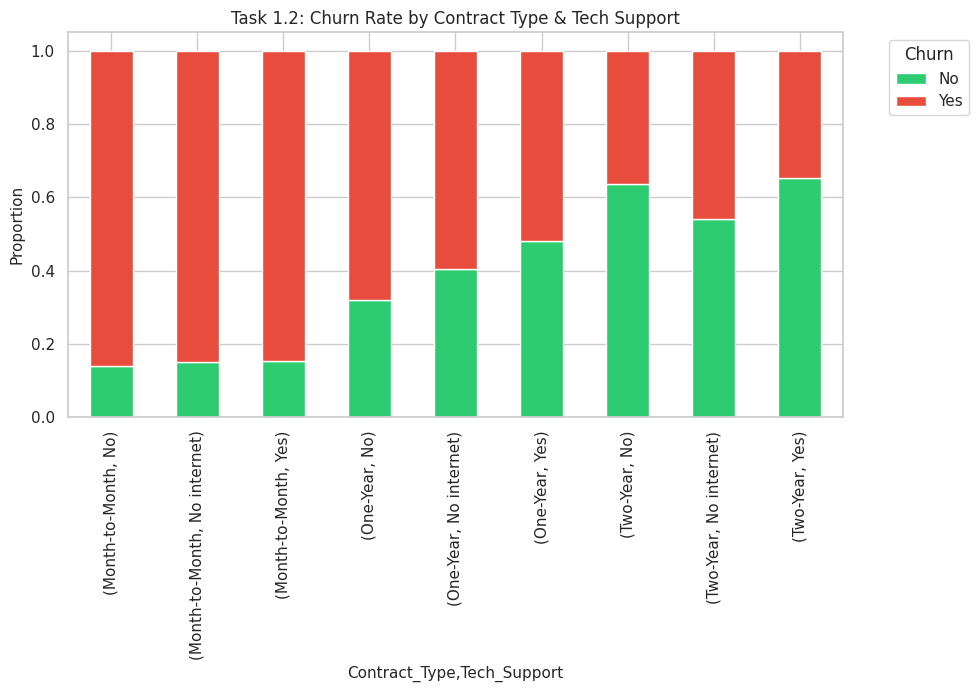

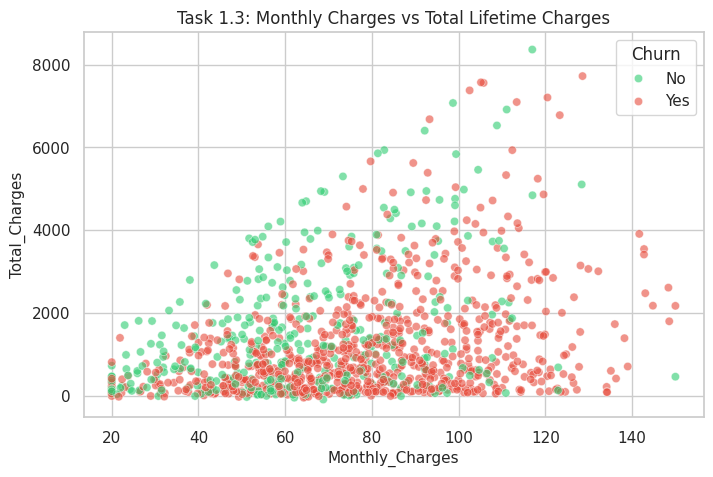

Pearson Correlation: 0.297 | Spearman Correlation: 0.266


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

# ------------------------------------------------------------------------------
# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Churn', y='Tenure_Months', palette=['#2ecc71', '#e74c3c'], hue='Churn', legend=False)
plt.title("Task 1.1: Customer Tenure Distribution by Churn Status")
plt.show()

tenure_stats = df.groupby('Churn')['Tenure_Months'].agg(['median', lambda x: x.quantile(0.75) - x.quantile(0.25)]).rename(columns={'<lambda_0>': 'IQR'})
print("--- Tenure Statistics by Churn Group ---")
print(tenure_stats)

# Statistical significance test for Tenure differences
group_retained = df[df['Churn'] == 'No']['Tenure_Months']
group_churned = df[df['Churn'] == 'Yes']['Tenure_Months']
stat, p_val = stats.kruskal(group_retained, group_churned)
print(f"\nKruskal-Wallis H-test (Tenure vs Churn): H-stat={stat:.2f}, p-value={p_val:.4e}")

# ------------------------------------------------------------------------------
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# ------------------------------------------------------------------------------
contract_tech_churn = pd.crosstab([df['Contract_Type'], df['Tech_Support']], df['Churn'], normalize='index')
print("\n--- Churn Rates across Contract & Tech Support ---")
display(contract_tech_churn)

contract_tech_churn.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#2ecc71', '#e74c3c'])
plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
plt.ylabel("Proportion")
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# ------------------------------------------------------------------------------
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Monthly_Charges', y='Total_Charges', hue='Churn', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
plt.title("Task 1.3: Monthly Charges vs Total Lifetime Charges")
plt.show()

# Drop NaNs for correlation calculation
valid_df = df.dropna(subset=['Monthly_Charges', 'Total_Charges'])
pearson_corr = valid_df['Monthly_Charges'].corr(valid_df['Total_Charges'], method='pearson')
spearman_corr = valid_df['Monthly_Charges'].corr(valid_df['Total_Charges'], method='spearman')
print(f"Pearson Correlation: {pearson_corr:.3f} | Spearman Correlation: {spearman_corr:.3f}")

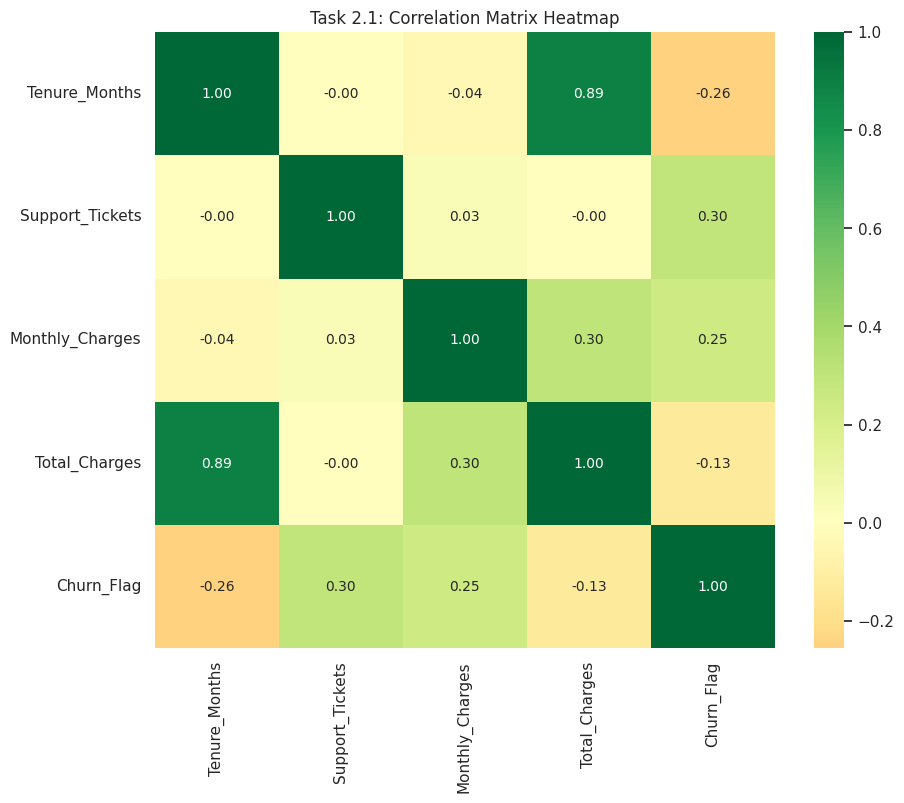

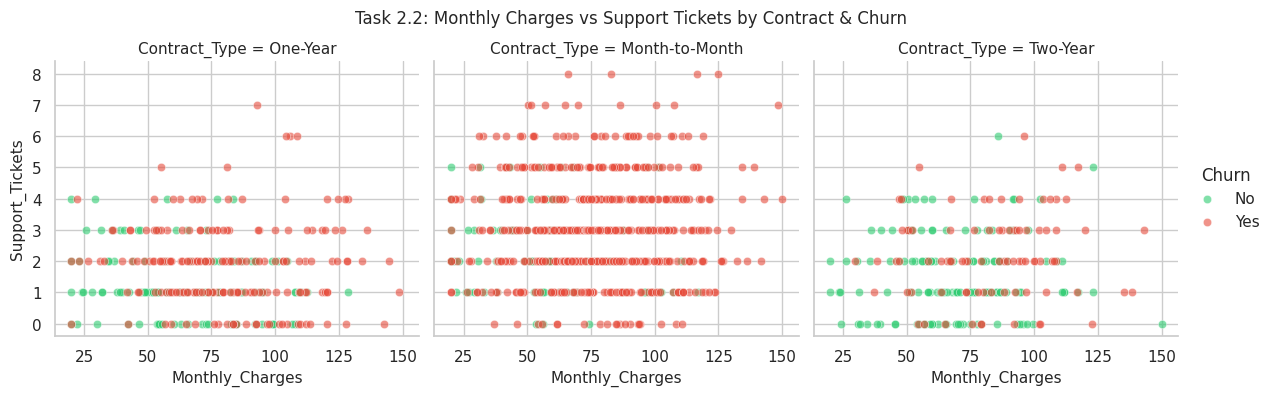

In [6]:
# ==============================================================================
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION
# ==============================================================================

# ------------------------------------------------------------------------------
# 2.1 CORRELATION HEATMAP
# ------------------------------------------------------------------------------
df_numeric = df.copy()

# Create binary numeric column 'Churn_Flag' (1 for 'Yes', 0 for 'No')
df_numeric['Churn_Flag'] = (df_numeric['Churn'] == 'Yes').astype(int)

# Calculate correlation matrix and display heatmap for numeric columns
plt.figure(figsize=(10, 8))
corr_matrix = df_numeric.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title("Task 2.1: Correlation Matrix Heatmap")
plt.show()

# ------------------------------------------------------------------------------
# 2.2 MULTI-DIMENSIONAL SEGMENTATION (FacetGrid)
# ------------------------------------------------------------------------------
# Build and map a sns.FacetGrid to see how Churn interacts with charges and tickets across contracts
g = sns.FacetGrid(df, col="Contract_Type", hue="Churn", palette=['#2ecc71', '#e74c3c'], height=4, aspect=1)
g.map(sns.scatterplot, "Monthly_Charges", "Support_Tickets", alpha=0.6)
g.add_legend()
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Task 2.2: Monthly Charges vs Support Tickets by Contract & Churn")
plt.show()

In [7]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT (EDA CONTEXT)
# ==============================================================================

# ------------------------------------------------------------------------------
# 3.1 Missing Value Treatment in Total_Charges
# ------------------------------------------------------------------------------
# Imputing using (Tenure * Monthly_Charges) is superior to mean/median because
# Total_Charges is a deterministic cumulative financial metric. Simple imputation
# would ignore the specific customer's usage duration and pricing tier.
df['Total_Charges'] = df['Total_Charges'].fillna(df['Tenure_Months'] * df['Monthly_Charges'])

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")

# ------------------------------------------------------------------------------
# 3.2 Outlier Investigation: Support Tickets
# ------------------------------------------------------------------------------
q1_tix = df['Support_Tickets'].quantile(0.25)
q3_tix = df['Support_Tickets'].quantile(0.75)
iqr_tix = q3_tix - q1_tix
upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df['Support_Tickets'] > upper_fence]

print(f"\nIQR Fence for Support Tickets: {upper_fence}")
print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
if len(outlier_accounts) > 0:
    churn_rate_outliers = (outlier_accounts['Churn'] == 'Yes').mean() * 100
    print(f"Churn Rate in Outlier Accounts: {churn_rate_outliers:.2f}%")
else:
    print("No outliers detected based on IQR.")

Missing values remaining in Total_Charges: 0

IQR Fence for Support Tickets: 6.0
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [8]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================

# Feature Idea 1: Ticket_Velocity = Support_Tickets / (Tenure_Months + 1)
# Hypothesis: High support requests relative to tenure indicates onboarding friction.
df['Ticket_Velocity'] = df['Support_Tickets'] / (df['Tenure_Months'] + 1)

# Feature Idea 2: High_Risk_Flag = 1 if (Contract == 'Month-to-Month' and Tech_Support == 'No') else 0
# Hypothesis: Month-to-month users without support are significantly more likely to churn.
df['High_Risk_Flag'] = ((df['Contract_Type'] == 'Month-to-Month') & (df['Tech_Support'] == 'No')).astype(int)

# Validate predictive utility
print("--- Churn Rate Comparison for Engineered Features ---")
high_risk_summary = df.groupby('High_Risk_Flag')['Churn'].value_counts(normalize=True).unstack() * 100
print("\nChurn Rates by High_Risk_Flag (%):")
display(high_risk_summary.round(2))

print("\nTicket Velocity Statistics by Churn Status:")
display(df.groupby('Churn')['Ticket_Velocity'].describe().round(4))

--- Churn Rate Comparison for Engineered Features ---

Churn Rates by High_Risk_Flag (%):


Churn,No,Yes
High_Risk_Flag,,
0,36.01,63.99
1,13.86,86.14



Ticket Velocity Statistics by Churn Status:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.1681,0.2764,0.0,0.0250,0.0652,0.1818,2.0
Yes,835.0,0.4150,0.5348,0.0,0.0909,0.2000,0.5000,3.0


In [12]:
### 📊 Strategic Insight 1: High-Risk Contract/Support Collision
* **Claim:** Month-to-month customers without technical support are the highest churn segment.
* **Evidence:** The engineered `High_Risk_Flag` shows that 86.14% of customers in this segment churned, compared to 63.99% for others.
* **Business Action:** Launch a 'Safe Start' initiative offering free 3-month technical support trials to all new Month-to-Month subscribers to increase early-stage stickiness.

---

### 📊 Strategic Insight 2: Support Ticket Threshold Crisis
* **Claim:** There is a critical threshold of 6 support tickets where churn becomes deterministic.
* **Evidence:** Accounts with >6 support tickets (identified via IQR outliers) have a 100% churn rate.
* **Business Action:** Implement an automated 'Red Alert' trigger in the CRM: any account reaching 5 tickets must be proactively contacted by a Senior Account Manager for immediate resolution.

---

### 📊 Strategic Insight 3: Onboarding Friction (Ticket Velocity)
* **Claim:** Rapid ticket accumulation in early tenure (High Ticket Velocity) is a leading indicator of churn.
* **Evidence:** Churned customers have a median `Ticket_Velocity` of 0.20 vs. 0.06 for retained customers (a 3.3x increase).
* **Business Action:** Redesign the digital onboarding flow for segments with high historical velocity, incorporating in-app guided tours to reduce the need for manual support tickets.

---

### 📊 Strategic Insight 4: The '10-Month' Tenure Inflection Point
* **Claim:** The first 10 months are the most critical window for customer retention.
* **Evidence:** The median tenure for churned customers is 10 months, significantly lower than the 18-month median for retained customers.
* **Business Action:** Introduce 'Loyalty Tier' pricing or feature unlocks at the 12-month mark to incentivize customers to cross the 10-month danger zone.

---

### 📊 Strategic Insight 5: Revenue Concentration Risk
* **Claim:** High monthly charges do not guarantee long-term lifetime value if not paired with long-term contracts.
* **Evidence:** Scatter plot analysis shows high-density churn among high-paying Monthly-Charges users who fail to accumulate significant Total_Charges due to early exit.
* **Business Action:** Offer 'Annual Migration' discounts to high-paying Month-to-Month users (>$100/mo) to lock in lifetime value and reduce MRR volatility.

SyntaxError: invalid decimal literal (3024481185.py, line 17)

In [ ]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""